In [1]:
# import libraries
import pickle
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
)

In [2]:
N_ITR = 10
DIRECTORY = "../benchmarks/results/zero/"
with open(DIRECTORY + "ftdf_100_pos.pkl", "rb") as f:
    pos_l = pickle.load(f)

with open(DIRECTORY + "ftdf_100_y.pkl", "rb") as f:
    y_l = pickle.load(f)


ftdf_acc_l = []
ftdf_auc_l = []
for j in range(N_ITR):
    ftdf_acc_l.append([])
    ftdf_auc_l.append([])

    for i in range(5):
        ftdf_acc_l[j].append(
            accuracy_score(y_l[j][i], np.argmax(pos_l[j][2 * i], axis=1))
        )
        ftdf_auc_l[j].append(
            roc_auc_score(y_l[j][i], np.array(pos_l[j][2 * i]), multi_class="ovr")
        )

df_acc_l = []
df_auc_l = []
for j in range(N_ITR):
    df_acc_l.append([])
    df_auc_l.append([])

    for i in range(5):
        df_acc_l[j].append(
            accuracy_score(y_l[j][i], np.argmax(pos_l[j][2 * i + 1], axis=1))
        )
        df_auc_l[j].append(
            roc_auc_score(y_l[j][i], np.array(pos_l[j][2 * i + 1]), multi_class="ovr")
        )

In [3]:
with open(DIRECTORY + "xgb_100_pos.pkl", "rb") as f:
    pos_l = pickle.load(f)

with open(DIRECTORY + "xgb_100_y.pkl", "rb") as f:
    y_l = pickle.load(f)


xgb_acc_l = []
xgb_auc_l = []
for j in range(N_ITR):
    xgb_acc_l.append([])
    xgb_auc_l.append([])

    for i in range(5):
        xgb_acc_l[j].append(accuracy_score(y_l[j][i], np.argmax(pos_l[j][i], axis=1)))
        xgb_auc_l[j].append(
            roc_auc_score(y_l[j][i], np.array(pos_l[j][i]), multi_class="ovr")
        )

In [4]:
ftdf_acc_l_full = np.concatenate(ftdf_acc_l)
df_acc_l_full = np.concatenate(df_acc_l)
xgb_acc_l_full = np.concatenate(xgb_acc_l)

ftdf_auc_l_full = np.concatenate(ftdf_auc_l)
df_auc_l_full = np.concatenate(df_auc_l)
xgb_auc_l_full = np.concatenate(xgb_auc_l)

ftdf_df_1 = pd.DataFrame()
ftdf_df_1["Score"] = ftdf_acc_l_full
ftdf_df_1["Classifier"] = "XForest-Zero"
ftdf_df_1["Metric"] = "Accuracy"

ftdf_df_2 = pd.DataFrame()
ftdf_df_2["Score"] = ftdf_auc_l_full
ftdf_df_2["Classifier"] = "XForest-Zero"
ftdf_df_2["Metric"] = "AUROC"

df_df_1 = pd.DataFrame()
df_df_1["Score"] = df_acc_l_full
df_df_1["Classifier"] = "RF"
df_df_1["Metric"] = "Accuracy"

df_df_2 = pd.DataFrame()
df_df_2["Score"] = df_auc_l_full
df_df_2["Classifier"] = "RF"
df_df_2["Metric"] = "AUROC"

xgb_df_1 = pd.DataFrame()
xgb_df_1["Score"] = xgb_acc_l_full
xgb_df_1["Classifier"] = "XGB"
xgb_df_1["Metric"] = "Accuracy"

xgb_df_2 = pd.DataFrame()
xgb_df_2["Score"] = xgb_auc_l_full
xgb_df_2["Classifier"] = "XGB"
xgb_df_2["Metric"] = "AUROC"

df = pd.concat(
    [ftdf_df_1, ftdf_df_2, df_df_1, df_df_2, xgb_df_1, xgb_df_2], ignore_index=True
)

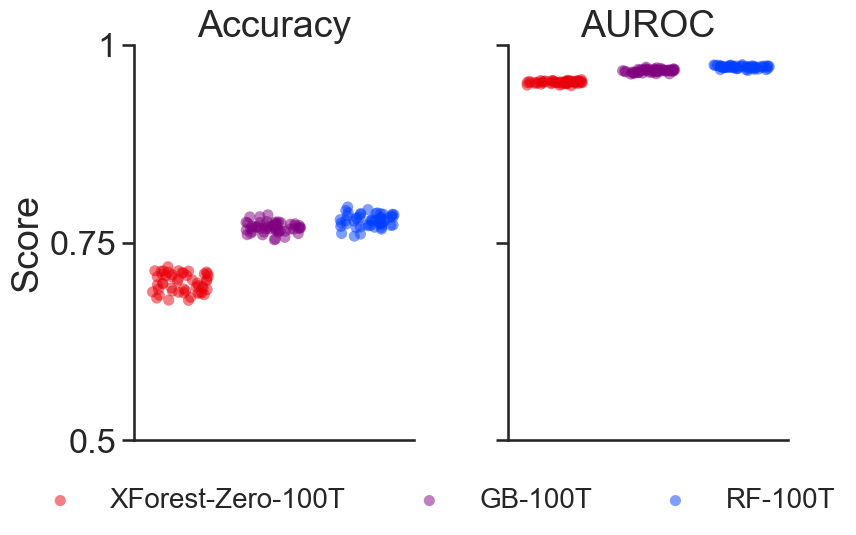

In [5]:
sns.set_theme(
    color_codes=True, palette="bright", style="ticks", context="talk", font_scale=1.5
)

palette_dict = {
    "XForest-Zero": "r",
    "XGB": "purple",
    "RF": "b",
}
g = sns.catplot(
    x="Classifier",
    y="Score",
    col="Metric",
    data=df,
    size=8,
    hue="Classifier",
    order=list(palette_dict.keys()),
    palette=palette_dict,
    alpha=0.5,
    height=6,
    aspect=0.7,
    jitter=0.3,
)
g.set(ylim=(0.5, 1), yticks=(0.5, 0.75, 1), xticks=([]))
g.set_xlabels("")
g.set_yticklabels([0.5, 0.75, 1])
g.set_titles("{col_name}")


leg = plt.legend(
    ["XForest-Zero-100T", "GB-100T", "RF-100T"],
    bbox_to_anchor=(0.53, 0.05),
    bbox_transform=plt.gcf().transFigure,
    ncol=3,
    loc="lower center",
    fontsize=20,
    frameon=False,
)
plt.savefig("f_mnist_zero.pdf", transparent=True, bbox_inches="tight")
plt.show()